# Recovering Lightcurves

The `Emitter.PointSource` class allows recovering lightcurves from objects
put into the FoV. The `.pop` option of `catalogs` allows for efficient creation
of such a fittable object.

We show a simple example here on recovering a simplified occultation shadow
of a star.

In [1]:
import astropy.units as u
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

import nyx
from nyx import (
    Airglow,
    EffectiveApertureInstrument,
    Geometry,
    Moon,
    Observation,
    Optimizer,
    Scene,
    SingleScattering,
    Stars,
    ZodiacalLight,
    freeze_all,
    unfreeze,
)

nyx.configure()

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 30) * u.nm,  # wavelength grid
    nside=16,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

instrument = EffectiveApertureInstrument.from_iactrace_table(geo, "CT1_aperture.npz")
atmosphere = SingleScattering.from_hg_ozone(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0, drift_order=2),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

In [3]:
location = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
# Choosing a simple example star around V=8
star_coord = SkyCoord.from_name("HD 21749")

seconds = np.arange(60.0)
times = Time("2021-01-12T22:00:00", scale="utc") + seconds * u.s
obs = Observation(location, times, star_coord, geo)

We pop out a star and give it a per-obs brightness curve. we set the transform to none, because log does not work with 0 values.

In [26]:
star = sources["GaiaDR3"].pop(star_coord, brightness=np.ones(obs.nobs), transform=None)
sources["star"] = star
scene = Scene.build(instrument, atmosphere, sources, obs)

In [27]:
# Creating an occultation dip:
occulted = (seconds >= 26) & (seconds < 34)
injected = np.where(occulted, 0.0, 1.0)

# Add random pointing offsets:
nshift = np.deg2rad(np.random.uniform(-0.05, 0.05, size=(scene.nobs["instrument"], 2)))
scene_t = scene.set("instruments.instrument.shift", jnp.array(nshift))

# Rendering the scene with the dip and adding noise
rng = np.random.default_rng(12)
rel_error = 0.02
rates = scene_t.set("sources.star.brightness", jnp.asarray(injected)).render()["instrument"]
data = jnp.asarray(np.asarray(rates) * rng.lognormal(0.0, rel_error, size=rates.shape))

We unfreeze pointing and brightness. In reality, you would float even more values.

In [28]:
%%time
start = unfreeze(freeze_all(scene), "sources.star.brightness")
start = unfreeze(start, "instruments.instrument.shift")


def residuals(scene):
    return (jnp.log(scene.render()["instrument"]) - jnp.log(data)) / rel_error


opt = Optimizer(residuals, optx.LBFGS(rtol=1e-6, atol=1e-6))
fitted, sol = opt.run(start, max_steps=512, throw=False)
errors = opt.errors(fitted)

print(opt.summary(fitted, sol))

FitSummary(
  chi2         57224.8
  d.o.f.       57420 = 57600 data - 180 free
  chi2/d.o.f.  0.996601
  solver       converged, 100 steps
)
CPU times: user 18.8 s, sys: 1.18 s, total: 20 s
Wall time: 9.66 s


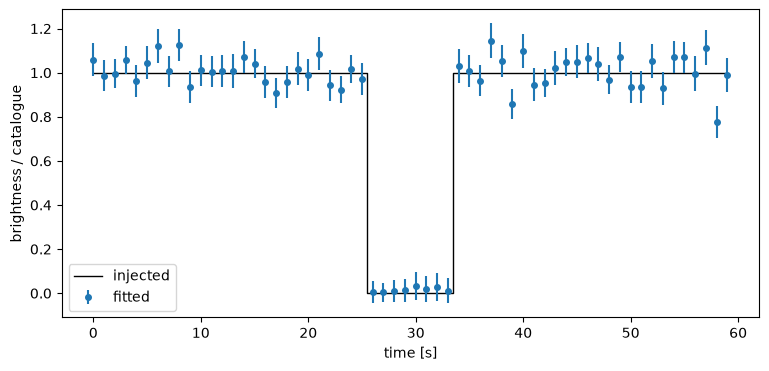

In [29]:
recovered = np.asarray(fitted.sources["star"].brightness.value)
sigma = np.asarray(errors.sources["star"].brightness.value)

plt.figure(figsize=(9, 4))
plt.step(seconds, injected, where="mid", color="k", lw=1, label="injected")
plt.errorbar(seconds, recovered, yerr=sigma, fmt="o", ms=4, label="fitted")
plt.xlabel("time [s]")
plt.ylabel("brightness / catalogue")
plt.legend()